In [1]:
import roboticstoolbox as rtb
from spatialmath import SE3
import numpy as np
import os

## URDF Model

In [2]:
robot = rtb.ERobot.URDF(os.path.abspath("robot.urdf"))

print(robot)

ERobot: robot, 6 joints (RRRRRR), dynamics, geometry
┌──────┬───────────┬───────┬───────────┬───────────────────────────────────────────────┐
│ link │   link    │ joint │  parent   │              ETS: parent to link              │
├──────┼───────────┼───────┼───────────┼───────────────────────────────────────────────┤
│    0 │ base_link │       │ BASE      │ SE3()                                         │
│    1 │ link0     │       │ base_link │ SE3()                                         │
│    2 │ link1     │     0 │ link0     │ SE3(0, 0, 0.065) ⊕ Rz(q0)                     │
│    3 │ link2     │     1 │ link1     │ SE3(0, 0.041, 0.042; -90°, -0°, 0°) ⊕ Rz(q1)  │
│    4 │ link3     │     2 │ link2     │ SE3(0, -0.098, 0.001; 180°, -0°, 0°) ⊕ Rz(q2) │
│    5 │ link4     │     3 │ link3     │ SE3(0, 0.041, 0.042; -90°, -0°, 0°) ⊕ Rz(q3)  │
│    6 │ link5     │     4 │ link4     │ SE3(0, 0.041, 0.057; -90°, -0°, 0°) ⊕ Rz(q4)  │
│    7 │ link6     │     5 │ link5     │ SE3(0, -0.041, 0

In [3]:
q = np.zeros(robot.n)
T = robot.fkine(q)

print(T)
print(f"RPY (deg): {np.round(np.degrees(T.rpy(order='xyz')), 2)}")

  -1        -3.59e-09  0         0         
   3.59e-09 -1        -1e-08     0.083     
   0        -1e-08     1         0.424     
   0         0         0         1         

RPY (deg): [180.   0.   0.]


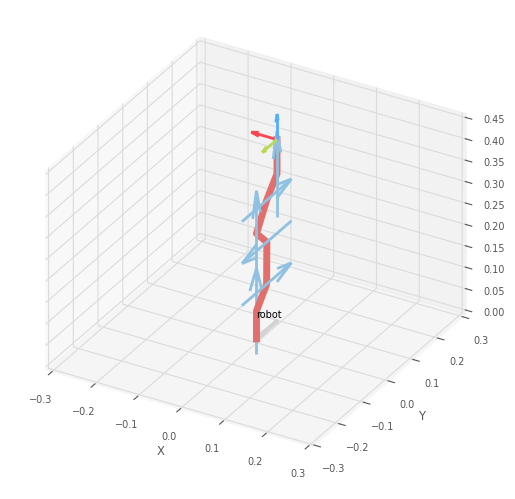

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'robot')

<Figure size 640x480 with 0 Axes>

In [4]:
q = np.zeros(robot.n)
robot.plot(q, backend="pyplot", limits=[-0.3,0.3,-0.3,0.3,0,0.45])

## Forward Kinematics

Position:  [0.0163 0.083  0.3599]
RPY (deg): [180.  45.   0.]


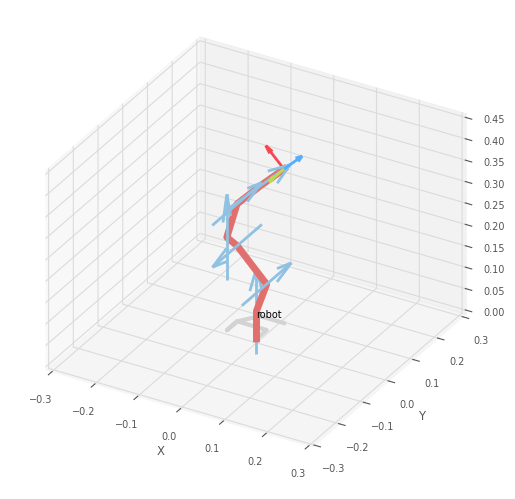

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'robot')

<Figure size 640x480 with 0 Axes>

In [5]:
q = np.array([0, -np.pi/4, -np.pi/4, 0, np.pi/4, 0])
T = robot.fkine(q)

print(f"Position:  {np.round(T.t, 4)}")
print(f"RPY (deg): {np.round(np.degrees(T.rpy(order='xyz')), 2)}")

robot.plot(q, backend="pyplot", limits=[-0.3,0.3,-0.3,0.3,0,0.45])

## Inverse Kinematics from FK result (should return the same q)

Found q:    [ 0.     -0.7854 -0.7855 -0.      0.7854  0.    ]
Expected q: [ 0.     -0.7854 -0.7854  0.      0.7854  0.    ]
Position error: 3.46e-06 m


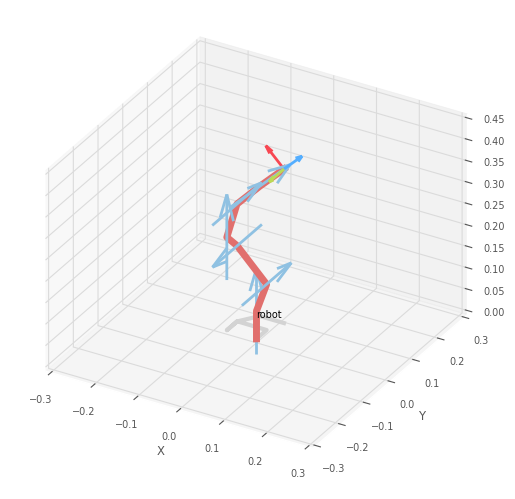

<Figure size 640x480 with 0 Axes>

In [6]:
sol = robot.ikine_LM(T, q0=np.zeros(6))

if sol.success:
    print(f"Found q:    {np.round(sol.q, 4)}")
    print(f"Expected q: {np.round(q, 4)}")

    T_verify = robot.fkine(sol.q)
    err_pos = np.linalg.norm(T_verify.t - T.t)
    print(f"Position error: {err_pos:.2e} m")

    robot.plot(sol.q, backend="pyplot", limits=[-0.3,0.3,-0.3,0.3,0,0.45])
else:
    print("IK cannot find solution!")

## Inverse Kinematics to a new position

Found q: [-1.8452 -0.6607  1.3686  0.     -1.1123  1.2964]
Position:      [0.12 0.12 0.02]
Goal position: [0.12 0.12 0.02]


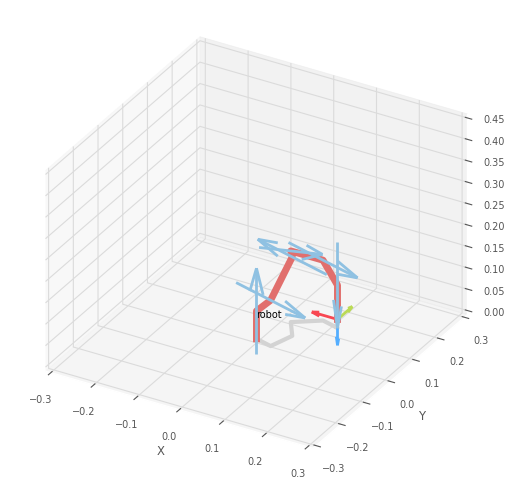

<Figure size 640x480 with 0 Axes>

In [7]:
q = SE3(0.12, 0.12, 0.02) * SE3.RPY(0, np.pi, 0, order="xyz")
sol = robot.ikine_LM(q, q0=np.zeros(6))

if sol.success:
    print(f"Found q: {np.round(sol.q, 4)}")
    print(f"Position:      {np.round(robot.fkine(sol.q).t, 4)}")
    print(f"Goal position: {np.round(q.t, 4)}")
    robot.plot(sol.q, backend="pyplot", limits=[-0.3,0.3,-0.3,0.3,0,0.45])
else:
    print("Point is not reachable!")

## Jacobian for q

In [8]:
J = robot.jacob0(q)
print(f"Shape: {J.shape} (6 x {robot.n})")
print(np.round(J, 4))

Shape: (6, 6) (6 x 6)
[[-0.0448  0.1713 -0.1183 -0.0448  0.0654  0.    ]
 [ 0.0698 -0.2667  0.1843  0.0698 -0.1018  0.    ]
 [-0.     -0.      0.      0.     -0.      0.    ]
 [ 0.      0.8415 -0.8415 -0.      0.8415 -0.    ]
 [ 0.      0.5403 -0.5403 -0.      0.5403 -0.    ]
 [ 1.      0.     -0.      1.      0.      1.    ]]
